In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import random
%matplotlib inline
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import sys
import os
sys.path.append(os.path.abspath('..'))  # adds project root to path

from src.data_cleaning import clean_data

# Set plotting style for a clean, professional look
sns.set_theme(style="whitegrid")

# Load the raw data and apply data cleaning steps

raw_df = pd.read_csv('../data/raw/online_retail_II.csv')
df = clean_data(raw_df)

print(f"Cleaned dataset ready. Shape: {df.shape}")
df.head()

Cleaned dataset ready. Shape: (954730, 13)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,date,year,month,week,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12-01,2009,12,49,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009,12,49,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009,12,49,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12-01,2009,12,49,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01,2009,12,49,30.0


We inspect to see how many unique products there are in the dataset and try to establish a product categorisation framework.

In [2]:
# Get unique descriptions only
unique_descs = df['Description'].dropna().unique()
print(f"Unique descriptions: {len(unique_descs):,}")

# Sample 100 random ones to eyeball
random.sample(list(unique_descs), 10)

Unique descriptions: 5,327


['PINK ROSEBUD & PEARL NECKLACE',
 'ZINC HEART LATTICE DOUBLE PLANTER',
 "POP'S GREASY SPOON METAL SIGN",
 'GLASS STAR FROSTED T-LIGHT HOLDER',
 'ENAMEL DINNER PLATE PANTRY',
 'BLUE WHITE SCARF HOT WATER BOTTLE',
 "YOU'RE CONFUSING ME METAL SIGN ",
 'WRAP ALPHABET DESIGN',
 'BLACK CHAMPAGNE GLASS',
 'FLOWER BLUE CLOCK WITH SUCKER']

Trying keyword matching for categorising products in the dataset (using the `Description` column).<br>
<i>
<b>Category keyword map:</b><br>
Keys are category names. Values are lowercase keywords matched against `Description.lower()`.<br>
Order within each list is not significant - any match assigns the category.<br>
Priority order across categories is handled in `assign_category()` - `Seasonal` is checked first.
</i>

In [3]:
# defining keywords for categorisation
CATEGORY_KEYWORDS = {
    "Seasonal & Festive": [
        "christmas", "xmas", "easter", "halloween", "valentine",
        "advent", "nativity", "snowman", "snowflake", "reindeer",
        "santa", "bauble", "wreath", "tinsel"
    ],
    "Candles & Lighting": [
        "candle", "tealight", "tea light", "lantern", "lamp",
        "nightlight", "night light", "candleholder", "candle holder",
        "sconce", "torch", "fairy light"
    ],
    "Kitchen & Dining": [
        "mug", "cup", "plate", "bowl", "glass", "teapot", "jug",
        "jar", "bottle", "cake", "baking", "cutlery", "spoon",
        "fork", "knife", "tin", "colander", "cafetiere", "tray",
        "chopping board", "kitchen", "dining", "napkin", "coaster"
    ],
    "Home Decor & Accessories": [
        "frame", "sign", "clock", "plaque", "cushion", "vase",
        "ornament", "figurine", "mirror", "bunting", "banner",
        "print", "poster", "wall", "door", "doorstop", "hook",
        "peg", "hanger", "drawer", "knob"
    ],
    "Bags & Totes": [
        "bag", "tote", "shopper", "purse", "pouch", "backpack",
        "satchel", "holdall"
    ],
    "Stationery & Cards": [
        "card", "notebook", "diary", "pen", "pencil", "calendar",
        "wrap", "ribbon", "tag", "sticker", "label", "envelope",
        "notepad", "rubber", "ruler", "stamp"
    ],
    "Garden & Outdoor": [
        "garden", "bird", "plant", "pot", "outdoor", "watering",
        "seed", "trowel", "fence", "hedgehog", "bee", "butterfly",
        "floral", "flower", "botanical"
    ],
}

In [4]:
def assign_category(description: str) -> str:
    """
    Assigns a retail category to a product based on keyword matching.

    Args:
        description: Raw product description string from the Description column.

    Returns:
        Category name as a string. Returns 'Other' if no keywords match.
    """
    if not isinstance(description, str):
        return "Other"

    desc = description.lower()

    # Define priority order explicitly - Seasonal must be first
    priority_order = [
        "Seasonal & Festive",
        "Candles & Lighting",
        "Kitchen & Dining",
        "Home Decor & Accessories",
        "Bags & Totes",
        "Stationery & Cards",
        "Garden & Outdoor",
    ]

    for category in priority_order:
        keywords = CATEGORY_KEYWORDS[category]
        if any(kw in desc for kw in keywords):
            return category

    return "Other"

<i>The priority order is hardcoded explicitly inside the function rather than relying on dictionary insertion order. This makes the logic transparent and immune to any Python version edge cases. If we ever add a new category and want it checked before another, just change one line in the `priority_order` list.</i>

In [5]:
df["category"] = df["Description"].apply(assign_category)

df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,date,year,month,week,Revenue,category
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12-01,2009,12,49,83.4,Seasonal & Festive
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009,12,49,81.0,Other
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12-01,2009,12,49,81.0,Other
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12-01,2009,12,49,100.8,Home Decor & Accessories
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01,2009,12,49,30.0,Other
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,2009-12-01,2009,12,49,39.6,Garden & Outdoor
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12-01,2009,12,49,30.0,Kitchen & Dining
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom,2009-12-01,2009,12,49,59.5,Home Decor & Accessories
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom,2009-12-01,2009,12,49,30.6,Kitchen & Dining
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom,2009-12-01,2009,12,49,45.0,Kitchen & Dining


We've categorised the products. Now it's time to do some sanity checks to see if the number of products in each category are within expected range.

In [6]:
category_counts = (
    df.groupby("category")
    .agg(
        unique_skus=("StockCode", "nunique"),
        transaction_rows=("StockCode", "count"),
        earliest_sale=("InvoiceDate", "min"),
        latest_sale=("InvoiceDate", "max"),
    )
    .reset_index()
)

category_counts["pct_of_skus"] = (
    category_counts["unique_skus"] / category_counts["unique_skus"].sum() * 100
).round(2)

category_counts = category_counts.sort_values("unique_skus", ascending=False).reset_index(drop=True)

print(f"Total unique SKUs: {category_counts['unique_skus'].sum():,}")
print(f"Total transactions: {category_counts['transaction_rows'].sum():,}")
print()
category_counts

Total unique SKUs: 4,944
Total transactions: 954,730



,category,unique_skus,transaction_rows,earliest_sale,latest_sale,pct_of_skus
0,Other,1606,259745,2009-12-01 07:45:00,2011-12-09 12:49:00,32.48
1,Kitchen & Dining,969,228818,2009-12-01 07:45:00,2011-12-09 12:49:00,19.60
2,Home Decor & Accessories,673,157966,2009-12-01 07:45:00,2011-12-09 12:49:00,13.61
3,Stationery & Cards,459,80863,2009-12-01 09:08:00,2011-12-09 12:20:00,9.28
4,Garden & Outdoor,374,63514,2009-12-01 07:45:00,2011-12-09 12:19:00,7.56
5,Candles & Lighting,347,34210,2009-12-01 09:57:00,2011-12-09 12:31:00,7.02
6,Seasonal & Festive,319,53170,2009-12-01 07:45:00,2011-12-09 12:20:00,6.45
7,Bags & Totes,197,76444,2009-12-01 09:24:00,2011-12-09 12:23:00,3.98


Let us check if the same `StockCode` appears with two slightly different descriptions.

In [7]:
# Check if any StockCode maps to more than one category
sku_category_counts = (
    df.groupby("StockCode")["category"]
    .nunique()
    .rename("num_categories")
    .reset_index()
)

conflicted = sku_category_counts[sku_category_counts["num_categories"] > 1]

print(f"SKUs with more than one category assigned: {len(conflicted):,}")
print()
conflicted.head(-5)
conflicted["num_categories"].unique()

SKUs with more than one category assigned: 81



,StockCode,num_categories
155,17107D,2
185,20615,2
220,20681,2
271,20750,2
273,20752,2
...,...,...
3992,84905,2
3993,84906,2
4008,84918,2
4009,84919,2


array([2], dtype=int64)

In [8]:
# Compute the modal category per StockCode
sku_modal_category = (
    df.groupby("StockCode")["category"]
    .agg(lambda x: x.mode()[0])
    .rename("modal_category")
    .reset_index()
)

# Overwrite category column with the modal category for every row
df = df.merge(sku_modal_category, on="StockCode", how="left")
df["category"] = df["modal_category"]
df = df.drop(columns=["modal_category"])

# Verify no conflicts remain
remaining_conflicts = (
    df.groupby("StockCode")["category"]
    .nunique()
    .rename("num_categories")
    .reset_index()
)

conflicted = remaining_conflicts[remaining_conflicts["num_categories"] > 1]
print(f"SKUs with more than one category after modal assignment: {len(conflicted):,}")

SKUs with more than one category after modal assignment: 0


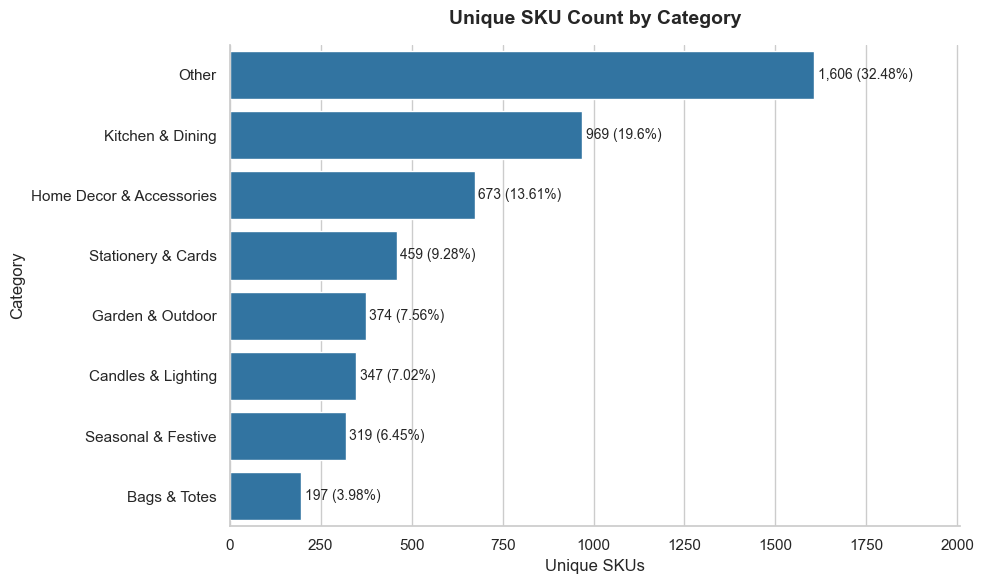

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=category_counts,
    x="unique_skus",
    y="category",
    order=category_counts.sort_values("unique_skus", ascending=False)["category"],
    color="#1f77b4",
    ax=ax,
)

ax.set_title("Unique SKU Count by Category", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Unique SKUs", fontsize=12)
ax.set_ylabel("Category", fontsize=12)

# Annotate each bar with count and percentage
for i, row in category_counts.sort_values("unique_skus", ascending=False).reset_index(drop=True).iterrows():
    ax.text(
        row["unique_skus"] + 10,
        i,
        f"{row['unique_skus']:,} ({row['pct_of_skus']}%)",
        va="center",
        fontsize=10,
    )

ax.set_xlim(0, category_counts["unique_skus"].max() * 1.25)
sns.despine()
plt.tight_layout()
plt.show();

I think there are too many products in the `Other` category. Let us check for the top descriptions.

In [16]:
import pathlib
# Top 10 most frequent descriptions in Other
other_descriptions = (
    df[df["category"] == "Other"]
    .groupby("Description")["StockCode"]
    .nunique()
    .rename("unique_skus")
    .reset_index()
    .sort_values("unique_skus", ascending=False)
)

print("Top 10 most frequent descriptions in Other:")
print(other_descriptions.head(10).to_string(index=False))

# Export all Other descriptions to txt
output_path = pathlib.Path("../notebooks/other_descriptions.txt")
other_descriptions["Description"].to_csv(output_path, index=False, header=False)
print(f"\nExported {len(other_descriptions):,} descriptions to {output_path}")

Top 10 most frequent descriptions in Other:
                      Description  unique_skus
        ENAMEL PINK TEA CONTAINER            2
      ANT WHITE WIRE HEART SPIRAL            2
  SET OF 4 ENGLISH ROSE PLACEMATS            2
           ART LIGHTS,FUNK MONKEY            2
        EDWARDIAN PARASOL NATURAL            2
HANGING HEART ZINC T-LIGHT HOLDER            2
      ICON PLACEMAT POP ART ELVIS            2
              FROSTED WHITE BASE             2
     SET OF 4 POLKADOT PLACEMATS             2
         SCOTTIES CHILDRENS APRON            2

Exported 1,680 descriptions to ..\notebooks\other_descriptions.txt
